# Collect Results

Clean comparison notebook for pretrained checkpoints versus the models we SFT-ed or GRPO-ed.

- The notebook normalizes metadata from `response_csv`, not from the often-messy summary columns.
- It deduplicates repeated rows for the same response file.
- The default comparison is focused on the configs that exist for the GRPO run.

If you refresh evaluations first, run:
```bash
bash experiments/run_scripts/eval_grpo_v2_cancer_eq.sh
```


In [14]:
import os
import re
from pathlib import Path

import pandas as pd

REPO_ROOT = Path.cwd()
if REPO_ROOT.name == "experiments" and not (REPO_ROOT / "experiments").exists():
    REPO_ROOT = REPO_ROOT.parent

os.environ.setdefault("MPLCONFIGDIR", str(REPO_ROOT / ".matplotlib"))

import matplotlib.pyplot as plt
import seaborn as sns

pd.set_option("display.max_rows", 200)
pd.set_option("display.max_columns", 200)
pd.set_option("display.width", 160)

SUMMARY_CSV = REPO_ROOT / "experiments" / "out" / "experiment1" / "sachs_summary.csv"

STYLE_CHOICES = [
    "summary_joint",
    "names_only",
    "matrix",
    "summary",
    "payload_topk",
    "payload",
    "cases",
]
STYLE_RE = "|".join(sorted(STYLE_CHOICES, key=len, reverse=True))
RESPONSE_RE = re.compile(
    rf"^responses_obs(?P<obs_n>\d+)_int(?P<int_n>\d+)_shuf(?P<shuffle>\d+)_p(?P<num_prompts>\d+)_(?P<prefix>.*?)(?P<prompt_style>{STYLE_RE})_(?P<model_raw>.+)$"
)
NAMES_ONLY_RE = re.compile(r"^responses_names_only_p(?P<num_prompts>\d+)_(?P<model_raw>.+)$")

MODEL_ALIASES = {
    "sft": (
        "Qwen3-4B-Thinking-2507",
        "SFT",
        "Qwen3-4B-Thinking-2507 (SFT)",
    ),
    "grpo_v2_cancer_eq": (
        "Qwen3-4B-Thinking-2507",
        "GRPO",
        "Qwen3-4B-Thinking-2507 (GRPO v2 cancer+eq)",
    ),
}
METHOD_LABELS = {
    "summary_joint": "Summary-Joint",
    "matrix": "Tabular",
    "names_only": "Name-Only",
    "baseline": "ENCO",
    "enco": "ENCO",
}


def parse_response_metadata(response_csv):
    stem = Path(str(response_csv)).stem
    meta = {
        "obs_n": pd.NA,
        "int_n": pd.NA,
        "shuffle": pd.NA,
        "num_prompts": pd.NA,
        "prompt_style": pd.NA,
        "model_raw": pd.NA,
        "anonymize": pd.NA,
        "cot_hint": False,
        "thinking_tags": False,
    }

    names_match = NAMES_ONLY_RE.match(stem)
    if names_match:
        meta.update(
            {
                "num_prompts": int(names_match.group("num_prompts")),
                "prompt_style": "names_only",
                "model_raw": names_match.group("model_raw"),
                "anonymize": 0,
            }
        )
        return meta

    match = RESPONSE_RE.match(stem)
    if not match:
        return meta

    prefix = match.group("prefix") or ""
    meta.update(
        {
            "obs_n": int(match.group("obs_n")),
            "int_n": int(match.group("int_n")),
            "shuffle": int(match.group("shuffle")),
            "num_prompts": int(match.group("num_prompts")),
            "prompt_style": match.group("prompt_style"),
            "model_raw": match.group("model_raw"),
            "anonymize": int("anon_" in prefix),
            "cot_hint": "cothint_" in prefix,
            "thinking_tags": "thinktags_" in prefix,
        }
    )
    return meta


def canonicalize_model(model_raw):
    if pd.isna(model_raw):
        return pd.Series(
            {
                "model_family": pd.NA,
                "tuning": pd.NA,
                "display_model": pd.NA,
            }
        )

    model_raw = str(model_raw)
    if model_raw in MODEL_ALIASES:
        model_family, tuning, display_model = MODEL_ALIASES[model_raw]
        return pd.Series(
            {
                "model_family": model_family,
                "tuning": tuning,
                "display_model": display_model,
            }
        )

    return pd.Series(
        {
            "model_family": model_raw,
            "tuning": "Pretrained",
            "display_model": model_raw,
        }
    )


def config_label(obs_n, int_n):
    if pd.isna(obs_n) or pd.isna(int_n):
        return "n/a"
    return f"obs={int(obs_n)}, int={int(int_n)}"


def dedupe_summary_rows(df):
    score_cols = [
        col
        for col in [
            "avg_f1",
            "avg_shd",
            "consensus_f1",
            "consensus_shd",
            "valid_rows",
            "num_rows",
            "model",
            "prompt_style",
        ]
        if col in df.columns
    ]
    out = df.copy()
    out["_row_score"] = out[score_cols].notna().sum(axis=1)
    out = out.sort_values(["response_csv", "_row_score"])
    out = out.drop_duplicates(subset=["response_csv"], keep="last")
    return out.drop(columns="_row_score")


def load_clean_results(summary_csv=SUMMARY_CSV):
    df = pd.read_csv(summary_csv).copy()

    if "response_csv" not in df.columns and "csv" in df.columns:
        df = df.rename(columns={"csv": "response_csv"})
    if "response_csv" not in df.columns:
        raise ValueError(f"Missing response_csv column in {summary_csv}")
    if "evaluated" not in df.columns:
        df["evaluated"] = 1

    df = dedupe_summary_rows(df)

    meta = df["response_csv"].apply(parse_response_metadata).apply(pd.Series)
    for col in meta.columns:
        df[col] = meta[col]

    df = pd.concat([df, df["model_raw"].apply(canonicalize_model)], axis=1)
    df["method"] = df["prompt_style"].map(METHOD_LABELS)
    df["setting"] = "named"

    anon_mask = pd.to_numeric(df["anonymize"], errors="coerce").fillna(0).astype(int).eq(1)
    cot_mask = df["cot_hint"].fillna(False)
    df.loc[anon_mask, "setting"] = "anon"
    df.loc[cot_mask, "setting"] = df.loc[cot_mask, "setting"] + " + CoT"

    for col in ["evaluated", "obs_n", "int_n", "avg_f1", "avg_shd", "valid_rows", "num_rows"]:
        if col in df.columns:
            df[col] = pd.to_numeric(df[col], errors="coerce")

    df = df[df["evaluated"].fillna(0).eq(1)].copy()
    df = df[df["display_model"].notna() & df["method"].notna()].copy()
    df = df[df["avg_f1"].notna() & df["avg_shd"].notna()].copy()
    df["config_label"] = [config_label(obs_n, int_n) for obs_n, int_n in zip(df["obs_n"], df["int_n"])]

    group_cols = [
        "display_model",
        "model_family",
        "tuning",
        "method",
        "setting",
        "anonymize",
        "cot_hint",
        "obs_n",
        "int_n",
        "config_label",
    ]
    return (
        df.groupby(group_cols, dropna=False, as_index=False)
        .agg(
            avg_f1=("avg_f1", "mean"),
            avg_shd=("avg_shd", "mean"),
            valid_rows=("valid_rows", "sum"),
            num_rows=("num_rows", "sum"),
            runs=("response_csv", "count"),
        )
        .sort_values(["display_model", "method", "setting", "obs_n", "int_n"])
        .reset_index(drop=True)
    )


def summarize_availability(results):
    return (
        results.groupby(["display_model", "tuning", "method", "setting"], as_index=False)
        .agg(
            configs=("config_label", lambda s: ", ".join(sorted(set(s)))),
            runs=("runs", "sum"),
        )
        .sort_values(["display_model", "method", "setting"])
        .reset_index(drop=True)
    )


def comparison_table(results, models=None, methods=None, settings=None, configs=None):
    sub = results.copy()
    if models:
        sub = sub[sub["display_model"].isin(models)]
    if methods:
        sub = sub[sub["method"].isin(methods)]
    if settings:
        sub = sub[sub["setting"].isin(settings)]
    if configs:
        wanted = set(configs)
        pairs = sub[["obs_n", "int_n"]].apply(
            lambda row: (int(row.iloc[0]), int(row.iloc[1])) if row.notna().all() else None,
            axis=1,
        )
        sub = sub[pairs.isin(wanted)]
    return sub.sort_values(["method", "setting", "obs_n", "int_n", "display_model"]).reset_index(drop=True)


def wide_metric_table(compare_df, metric="avg_f1"):
    return (
        compare_df.pivot_table(
            index=["method", "setting", "config_label"],
            columns="display_model",
            values=metric,
            aggfunc="first",
        )
        .sort_index()
        .round(4)
    )



In [15]:
results = load_clean_results()
availability = summarize_availability(results)

print(f"Loaded {len(results)} clean result rows from {SUMMARY_CSV}")
display(availability)

display(
    results[
        [
            "display_model",
            "tuning",
            "method",
            "setting",
            "obs_n",
            "int_n",
            "avg_f1",
            "avg_shd",
            "valid_rows",
            "num_rows",
            "runs",
        ]
    ]
)



Loaded 25 clean result rows from /u/chenyuen0103/ENCO/experiments/out/experiment1/sachs_summary.csv


,display_model,tuning,method,setting,configs,runs
0,Qwen3-4B-Thinking-2507,Pretrained,Name-Only,named,n/a,1
1,Qwen3-4B-Thinking-2507,Pretrained,Summary-Joint,anon,"obs=0, int=200, obs=5000, int=0",2
2,Qwen3-4B-Thinking-2507,Pretrained,Summary-Joint,named,"obs=0, int=200, obs=5000, int=0, obs=5000, int=200",3
3,Qwen3-4B-Thinking-2507,Pretrained,Tabular,anon,"obs=0, int=200, obs=5000, int=0",2
4,Qwen3-4B-Thinking-2507,Pretrained,Tabular,named,"obs=0, int=200, obs=5000, int=0, obs=5000, int=200",3
5,Qwen3-4B-Thinking-2507 (GRPO v2 cancer+eq),GRPO,Summary-Joint,anon,"obs=5000, int=200",1
6,Qwen3-4B-Thinking-2507 (GRPO v2 cancer+eq),GRPO,Summary-Joint,anon + CoT,"obs=1000, int=50, obs=5000, int=200",2
7,Qwen3-4B-Thinking-2507 (GRPO v2 cancer+eq),GRPO,Summary-Joint,named,"obs=1000, int=50, obs=5000, int=200",2
8,Qwen3-4B-Thinking-2507 (SFT),SFT,Name-Only,named,n/a,1
9,Qwen3-4B-Thinking-2507 (SFT),SFT,Summary-Joint,named,"obs=0, int=50, obs=5000, int=200",3


,display_model,tuning,method,setting,obs_n,int_n,avg_f1,avg_shd,valid_rows,num_rows,runs
0,Qwen3-4B-Thinking-2507,Pretrained,Name-Only,named,NaN,NaN,0.299349,19.00000,3.0,5.0,1
1,Qwen3-4B-Thinking-2507,Pretrained,Summary-Joint,anon,0.0,200.0,0.444444,15.00000,3.0,5.0,1
2,Qwen3-4B-Thinking-2507,Pretrained,Summary-Joint,anon,5000.0,0.0,0.383333,17.60000,5.0,5.0,1
3,Qwen3-4B-Thinking-2507,Pretrained,Summary-Joint,named,0.0,200.0,0.360494,18.00000,3.0,5.0,1
4,Qwen3-4B-Thinking-2507,Pretrained,Summary-Joint,named,5000.0,0.0,0.441112,14.80000,5.0,5.0,1
5,Qwen3-4B-Thinking-2507,Pretrained,Summary-Joint,named,5000.0,200.0,0.444444,15.00000,1.0,5.0,1
6,Qwen3-4B-Thinking-2507,Pretrained,Tabular,anon,0.0,200.0,0.444444,15.00000,2.0,5.0,1
7,Qwen3-4B-Thinking-2507,Pretrained,Tabular,anon,5000.0,0.0,0.348404,17.80000,5.0,5.0,1
8,Qwen3-4B-Thinking-2507,Pretrained,Tabular,named,0.0,200.0,0.444444,15.50000,4.0,5.0,1
9,Qwen3-4B-Thinking-2507,Pretrained,Tabular,named,5000.0,0.0,0.391204,15.80000,5.0,5.0,1


In [16]:
SELECTED_MODELS = [
    "Qwen3-4B-Thinking-2507",
    "Qwen3-4B-Thinking-2507 (SFT)",
    "Qwen3-4B-Thinking-2507 (GRPO v2 cancer+eq)",
]
SELECTED_METHODS = ["Summary-Joint"]
SELECTED_SETTINGS = ["named", "anon", "anon + CoT"]
SELECTED_CONFIGS = [(5000, 200), (1000, 50)]

compare = comparison_table(
    results,
    models=SELECTED_MODELS,
    methods=SELECTED_METHODS,
    settings=SELECTED_SETTINGS,
    configs=SELECTED_CONFIGS,
)

compare



,display_model,model_family,tuning,method,setting,anonymize,cot_hint,obs_n,int_n,config_label,avg_f1,avg_shd,valid_rows,num_rows,runs
0,Qwen3-4B-Thinking-2507 (GRPO v2 cancer+eq),Qwen3-4B-Thinking-2507,GRPO,Summary-Joint,anon,1,False,5000.0,200.0,"obs=5000, int=200",0.307692,18.00000,1.0,5.0,1
1,Qwen3-4B-Thinking-2507 (GRPO v2 cancer+eq),Qwen3-4B-Thinking-2507,GRPO,Summary-Joint,anon + CoT,1,True,1000.0,50.0,"obs=1000, int=50",0.115428,28.00000,5.0,5.0,1
2,Qwen3-4B-Thinking-2507 (GRPO v2 cancer+eq),Qwen3-4B-Thinking-2507,GRPO,Summary-Joint,anon + CoT,1,True,5000.0,200.0,"obs=5000, int=200",0.173342,26.60000,5.0,5.0,1
3,Qwen3-4B-Thinking-2507 (GRPO v2 cancer+eq),Qwen3-4B-Thinking-2507,GRPO,Summary-Joint,named,0,False,1000.0,50.0,"obs=1000, int=50",0.105263,30.00000,2.0,5.0,1
4,Qwen3-4B-Thinking-2507,Qwen3-4B-Thinking-2507,Pretrained,Summary-Joint,named,0,False,5000.0,200.0,"obs=5000, int=200",0.444444,15.00000,1.0,5.0,1
5,Qwen3-4B-Thinking-2507 (GRPO v2 cancer+eq),Qwen3-4B-Thinking-2507,GRPO,Summary-Joint,named,0,False,5000.0,200.0,"obs=5000, int=200",0.084656,22.00000,2.0,5.0,1
6,Qwen3-4B-Thinking-2507 (SFT),Qwen3-4B-Thinking-2507,SFT,Summary-Joint,named,0,False,5000.0,200.0,"obs=5000, int=200",0.307059,18.71875,20.0,25.0,2


In [17]:
display(wide_metric_table(compare, metric="avg_f1"))
display(wide_metric_table(compare, metric="avg_shd"))



display_model                               Qwen3-4B-Thinking-2507  Qwen3-4B-Thinking-2507 (GRPO v2 cancer+eq)  Qwen3-4B-Thinking-2507 (SFT)
method        setting    config_label                                                                                                       
Summary-Joint anon       obs=5000, int=200                     NaN                                      0.3077                           NaN
              anon + CoT obs=1000, int=50                      NaN                                      0.1154                           NaN
                         obs=5000, int=200                     NaN                                      0.1733                           NaN
              named      obs=1000, int=50                      NaN                                      0.1053                           NaN
                         obs=5000, int=200                  0.4444                                      0.0847                        0.3071

display_model                               Qwen3-4B-Thinking-2507  Qwen3-4B-Thinking-2507 (GRPO v2 cancer+eq)  Qwen3-4B-Thinking-2507 (SFT)
method        setting    config_label                                                                                                       
Summary-Joint anon       obs=5000, int=200                     NaN                                        18.0                           NaN
              anon + CoT obs=1000, int=50                      NaN                                        28.0                           NaN
                         obs=5000, int=200                     NaN                                        26.6                           NaN
              named      obs=1000, int=50                      NaN                                        30.0                           NaN
                         obs=5000, int=200                    15.0                                        22.0                       18.7188

/tmp/ipykernel_4035630/2714077162.py:29: FutureWarning: 

The `ci` parameter is deprecated. Use `errorbar=None` for the same effect.

  sns.barplot(
/tmp/ipykernel_4035630/2714077162.py:29: FutureWarning: 

The `ci` parameter is deprecated. Use `errorbar=None` for the same effect.

  sns.barplot(


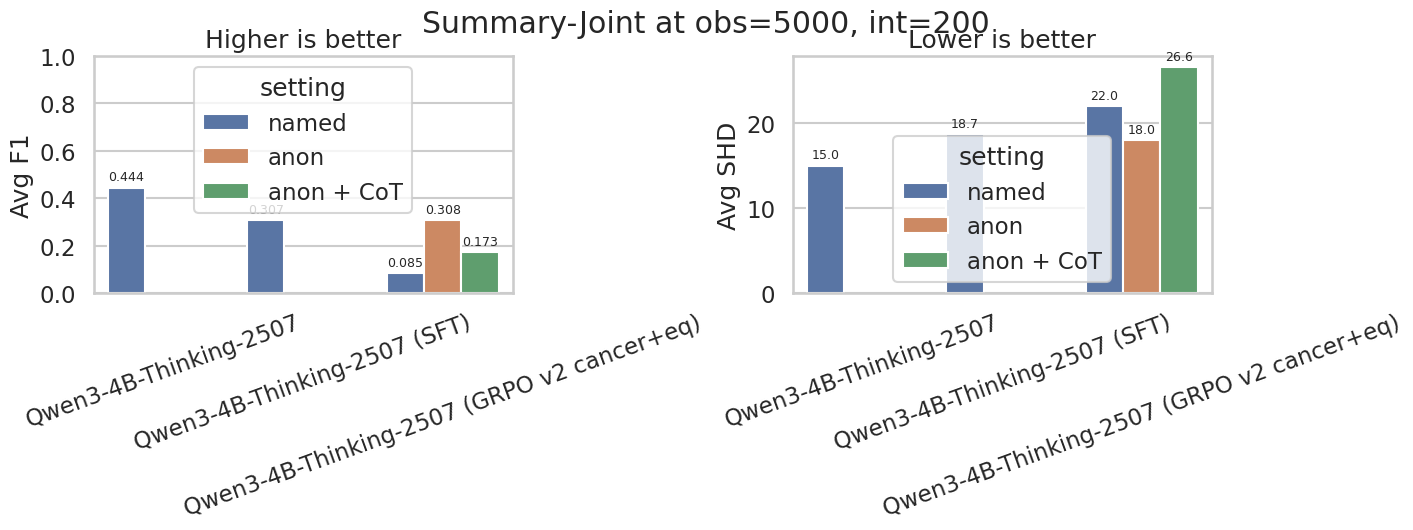

In [18]:
PLOT_METHOD = "Summary-Joint"
PLOT_CONFIG = (5000, 200)
PLOT_MODELS = SELECTED_MODELS
PLOT_SETTINGS = ["named", "anon", "anon + CoT"]

plot_df = comparison_table(
    results,
    models=PLOT_MODELS,
    methods=[PLOT_METHOD],
    settings=PLOT_SETTINGS,
    configs=[PLOT_CONFIG],
)

if plot_df.empty:
    print(f"No rows found for method={PLOT_METHOD} and config={PLOT_CONFIG}")
else:
    model_order = [m for m in PLOT_MODELS if m in plot_df["display_model"].unique()]
    setting_order = [s for s in PLOT_SETTINGS if s in plot_df["setting"].unique()]
    plot_label_map = {
        "Qwen3-4B-Thinking-2507": "Qwen3-4B\npretrained",
        "Qwen3-4B-Thinking-2507 (SFT)": "Qwen3-4B\nSFT",
        "Qwen3-4B-Thinking-2507 (GRPO v2 cancer+eq)": "Qwen3-4B\nGRPO v2",
    }
    plot_df = plot_df.copy()
    plot_df["plot_label"] = plot_df["display_model"].map(plot_label_map).fillna(plot_df["display_model"])
    plot_order = [plot_label_map.get(model_name, model_name) for model_name in model_order]

    sns.set_theme(style="whitegrid", context="talk")
    fig, axes = plt.subplots(1, 2, figsize=(14, 5), constrained_layout=True)

    panels = [
        (axes[0], "avg_f1", "Avg F1", "Higher is better", 0, 1.0, "{:.3f}"),
        (axes[1], "avg_shd", "Avg SHD", "Lower is better", None, None, "{:.1f}"),
    ]

    for ax, metric, ylabel, title, ymin, ymax, fmt in panels:
        sns.barplot(
            data=plot_df,
            x="plot_label",
            y=metric,
            hue="setting",
            order=plot_order,
            hue_order=setting_order,
            ci=None,
            ax=ax,
        )
        ax.set_title(title)
        ax.set_xlabel("")
        ax.set_ylabel(ylabel)
        ax.tick_params(axis="x", labelrotation=0)
        if ymin is not None or ymax is not None:
            ax.set_ylim(ymin, ymax)
        for container in ax.containers:
            labels = [fmt.format(value) if pd.notna(value) else "" for value in container.datavalues]
            ax.bar_label(container, labels=labels, padding=3, fontsize=9)

    fig.suptitle(f"{PLOT_METHOD} at obs={PLOT_CONFIG[0]}, int={PLOT_CONFIG[1]}", y=1.03)
    plt.show()

